<h1>Третья практическая, обработка изображений</h1>

In [38]:
import numpy as np
from glob import glob
import cv2
import os
from skimage.util import random_noise
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import mnist
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
%matplotlib inline

## Методы обработки изображений

### Геометрические преобразования

In [39]:
image_folder = 'sudoku dataset'
output_folder = 'geometry_preprocessing'

In [40]:
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [41]:
def read_dat_image(file_path, height=9, width=9):
    try:
        with open(file_path, 'r') as file:
            data = []
            for line in file:
                line = line.strip()
                if line and all(char.isdigit() or char.isspace() for char in line):
                    data.append(list(map(int, line.split())))
        data_array = np.array(data)
        if data_array.shape == (height, width):
            return data_array * 28  # Масштабирование для визуализации
        else:
            print(f"Неверные данные в файле {file_path}, пропуск...")
            return None
    except Exception as e:
        print(f"Ошибка при чтении {file_path}: {e}")
        return None


геометрические преобразования

In [42]:
def apply_geometric_transformations(image):
    rows, cols = image.shape[:2]

    # Поворот на 45 градусов
    rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), 45, 1)
    rotated = cv2.warpAffine(image, rotation_matrix, (cols, rows))

    # Сдвиг
    shift_matrix = np.float32([[1, 0, 50], [0, 1, 50]])
    shifted = cv2.warpAffine(image, shift_matrix, (cols, rows))

    # Масштабирование
    scaled = cv2.resize(image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)

    # Отражение по горизонтали
    flipped = cv2.flip(image, 0)

    # Проективное преобразование
    src_points = np.float32([[0, 0], [cols - 1, 0], [0, rows - 1], [cols - 1, rows - 1]])
    dst_points = np.float32([[0, 0], [cols - 1, 0], [cols // 4, rows - 1], [3 * cols // 4, rows - 1]])
    perspective_matrix = cv2.getPerspectiveTransform(src_points, dst_points)
    perspective_transformed = cv2.warpPerspective(image, perspective_matrix, (cols, rows))

    return rotated, shifted, scaled, flipped, perspective_transformed


регулировка яркости и контрастности

In [43]:
def adjust_brightness_contrast(image, brightness=0, contrast=1.0):
    return cv2.convertScaleAbs(image, alpha=contrast, beta=brightness)

In [44]:
image_paths = glob(os.path.join(image_folder, '*.jpg')) + glob(os.path.join(image_folder, '*.dat'))

for i, image_path in enumerate(image_paths):
    if image_path.endswith('.dat'):
        height, width = 9, 9  
        image = read_dat_image(image_path, height, width)
    
        if image is not None:
            image = cv2.cvtColor(image.astype(np.uint8), cv2.COLOR_GRAY2BGR)
    else:
        image = cv2.imread(image_path)

    if image is not None:
        rotated, shifted, scaled, flipped, perspective_transformed = apply_geometric_transformations(image)
        
        brightness = 50
        contrast = 1.5
        bright_contrast_adjusted = adjust_brightness_contrast(image, brightness, contrast)
        
        # Сохраняем результаты
        cv2.imwrite(os.path.join(output_folder, f'image_{i}_rotated.jpg'), rotated)
        cv2.imwrite(os.path.join(output_folder, f'image_{i}_shifted.jpg'), shifted)
        cv2.imwrite(os.path.join(output_folder, f'image_{i}_scaled.jpg'), scaled)
        cv2.imwrite(os.path.join(output_folder, f'image_{i}_flipped.jpg'), flipped)
        cv2.imwrite(os.path.join(output_folder, f'image_{i}_perspective.jpg'), perspective_transformed)
        cv2.imwrite(os.path.join(output_folder, f'image_{i}_bright_contrast.jpg'), bright_contrast_adjusted)
    else:
        print(f"Не удалось загрузить изображение: {image_path}")

### Применение фильтрации

функции, добавляющие шум

In [45]:
def add_gaussian_noise(image, mean=0, var=0.01):
    noise_img = random_noise(image, mode='gaussian', mean=mean, var=var)
    return np.array(255 * noise_img, dtype=np.uint8)

In [46]:
def add_salt_pepper_noise(image, amount=0.05):
    noise_img = random_noise(image, mode='s&p', amount=amount)
    return np.array(255 * noise_img, dtype=np.uint8)

In [47]:
def add_pepper_noise(image, amount=0.05):
    noisy_image = np.copy(image)
    num_peppers = np.ceil(amount * image.size).astype(int)
    coords = [np.random.randint(0, i - 1, num_peppers) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 0
    return noisy_image

In [48]:
def add_random_noise(image, noise_level=30):
    noise = np.random.randint(-noise_level, noise_level + 1, image.shape, dtype='int16')
    noisy_image = np.clip(image.astype('int16') + noise, 0, 255)
    return noisy_image.astype('uint8')


фильтрующие функции

In [49]:
def apply_average_filter(image, kernel_size=3):
    return cv2.blur(image, (kernel_size, kernel_size))

In [50]:
def apply_gaussian_filter(image, kernel_size=3):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)


In [51]:
def apply_median_filter(image, kernel_size=3):
    return cv2.medianBlur(image, kernel_size)

In [52]:
def apply_bilateral_filter(image, diameter=9, sigma_color=75, sigma_space=75):
    return cv2.bilateralFilter(image, diameter, sigma_color, sigma_space)

psnr

In [53]:
def calculate_psnr(original, denoised):
    return cv2.PSNR(original, denoised)

In [54]:
image_folder = 'sudoku dataset'
output_folder = 'filter_preprocessing'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [55]:
for filename in os.listdir(image_folder):
    image_path = os.path.join(image_folder, filename)
    image = None

    if filename.endswith('.jpg'):
        image = cv2.imread(image_path)
    
    if image is None:
        print(f"Failed to load image: {filename}")
        continue

    gaussian_noisy_image = add_gaussian_noise(image)
    salt_pepper_noisy_image = add_salt_pepper_noise(image)
    pepper_noisy_image = add_pepper_noise(image)
    random_noisy_image = add_random_noise(image)

    gaussian_filtered = apply_gaussian_filter(gaussian_noisy_image)
    salt_pepper_filtered = apply_median_filter(salt_pepper_noisy_image)
    pepper_filtered = apply_median_filter(pepper_noisy_image)
    random_filtered = apply_average_filter(random_noisy_image)
    bilateral_filtered = apply_bilateral_filter(gaussian_noisy_image)

    gaussian_psnr = calculate_psnr(image, gaussian_filtered)
    salt_pepper_psnr = calculate_psnr(image, salt_pepper_filtered)
    pepper_psnr = calculate_psnr(image, pepper_filtered)
    random_psnr = calculate_psnr(image, random_filtered)
    bilateral_psnr = calculate_psnr(image, bilateral_filtered)

    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_gaussian_noisy.jpg'), gaussian_noisy_image)
    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_salt_pepper_noisy.jpg'), salt_pepper_noisy_image)
    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_pepper_noisy.jpg'), pepper_noisy_image)
    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_random_noisy.jpg'), random_noisy_image)

    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_gaussian_filtered.jpg'), gaussian_filtered)
    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_salt_pepper_filtered.jpg'), salt_pepper_filtered)
    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_pepper_filtered.jpg'), pepper_filtered)
    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_random_filtered.jpg'), random_filtered)
    cv2.imwrite(os.path.join(output_folder, f'{filename[:-4]}_bilateral_filtered.jpg'), bilateral_filtered)

    print(f'Processed {filename}')
    print(f'PSNR for Gaussian noise: {gaussian_psnr:.2f} dB')
    print(f'PSNR for Salt and Pepper noise: {salt_pepper_psnr:.2f} dB')
    print(f'PSNR for Pepper noise: {pepper_psnr:.2f} dB')
    print(f'PSNR for Random noise: {random_psnr:.2f} dB')
    print(f'PSNR for Bilateral filter on Gaussian noise: {bilateral_psnr:.2f} dB\n')

Failed to load image: image1005.dat
Processed image1005.jpg
PSNR for Gaussian noise: 25.74 dB
PSNR for Salt and Pepper noise: 28.07 dB
PSNR for Pepper noise: 23.34 dB
PSNR for Random noise: 25.92 dB
PSNR for Bilateral filter on Gaussian noise: 28.72 dB

Failed to load image: image1009.dat
Processed image1009.jpg
PSNR for Gaussian noise: 27.14 dB
PSNR for Salt and Pepper noise: 33.11 dB
PSNR for Pepper noise: 25.22 dB
PSNR for Random noise: 28.42 dB
PSNR for Bilateral filter on Gaussian noise: 29.56 dB

Failed to load image: image1019.dat
Processed image1019.jpg
PSNR for Gaussian noise: 26.48 dB
PSNR for Salt and Pepper noise: 32.44 dB
PSNR for Pepper noise: 24.67 dB
PSNR for Random noise: 27.11 dB
PSNR for Bilateral filter on Gaussian noise: 29.26 dB

Failed to load image: image1024.dat
Processed image1024.jpg
PSNR for Gaussian noise: 27.56 dB
PSNR for Salt and Pepper noise: 34.65 dB
PSNR for Pepper noise: 25.52 dB
PSNR for Random noise: 29.46 dB
PSNR for Bilateral filter on Gaussian n

### Работа с контурами

In [56]:
output_dir = 'contour_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [57]:
def add_gaussian_noise(image, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, image.shape).astype('float32')
    noisy_image = cv2.add(image.astype('float32'), noise)
    return np.clip(noisy_image, 0, 255).astype('uint8')


In [58]:
# Функция для расчета MSE
def mse(imageA, imageB):
    return np.mean((imageA.astype("float") - imageB.astype("float")) ** 2)


In [59]:
# Функция для применения порогового значения
def apply_threshold(edges, threshold):
    _, thresholded_edges = cv2.threshold(edges, threshold, 255, cv2.THRESH_BINARY)
    return thresholded_edges

In [60]:
# Функция для получения контуров с различными методами
def get_contours(image, thresholds):
    edges = {}

    # Метод Робертса
    roberts_kernel_x = np.array([[1, 0], [0, -1]], dtype='float32')
    roberts_kernel_y = np.array([[0, 1], [-1, 0]], dtype='float32')
    roberts_edges = cv2.filter2D(image, -1, roberts_kernel_x) + cv2.filter2D(image, -1, roberts_kernel_y)
    for threshold in thresholds:
        edges[f'Roberts_{threshold}'] = apply_threshold(roberts_edges, threshold)

    # Метод Превитта
    previtt_kernel_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype='float32')
    previtt_kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype='float32')
    previtt_edges = cv2.filter2D(image, -1, previtt_kernel_x) + cv2.filter2D(image, -1, previtt_kernel_y)
    for threshold in thresholds:
        edges[f'Prewitt_{threshold}'] = apply_threshold(previtt_edges, threshold)

    # Метод Собела
    sobel_edges = cv2.Sobel(image, cv2.CV_64F, 1, 1, ksize=3)
    for threshold in thresholds:
        edges[f'Sobel_{threshold}'] = apply_threshold(sobel_edges, threshold)

    # Метод Лапласа
    laplacian_edges = cv2.Laplacian(image, cv2.CV_64F)
    for threshold in thresholds:
        edges[f'Laplacian_{threshold}'] = apply_threshold(laplacian_edges, threshold)

    # Метод Кэнни с динамическим порогом
    for threshold in thresholds:
        canny_edges = cv2.Canny(image, threshold, threshold * 2)
        edges[f'Canny_{threshold}'] = canny_edges

    return edges

In [61]:
# Загрузка изображений
image_folder = 'sudoku dataset'
images = glob(os.path.join(image_folder, '*.jpg')) + glob(os.path.join(image_folder, '*.png'))

In [62]:
# Пороговые значения для всех методов
thresholds = [50, 100, 150]

# Уровни шума для исследования
noise_levels = [10, 20, 30, 40, 50]

# Словарь для хранения MSE результатов
mse_results = {f'{method}_{threshold}': {sigma: [] for sigma in noise_levels} 
               for method in ['Roberts', 'Prewitt', 'Sobel', 'Laplacian', 'Canny']
               for threshold in thresholds}

In [63]:
# Анализ каждого изображения
for idx, image_path in enumerate(images):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Could not load image {image_path}")
        continue

    # Эталонное изображение контуров
    ideal_edges = cv2.Canny(image, 100, 200)

    for noise_level in noise_levels:
        noisy_image = add_gaussian_noise(image, sigma=noise_level)
        contours = get_contours(noisy_image, thresholds)

        # Сохранение контурных изображений и расчёт MSE
        for method, edges in contours.items():
            error = mse(edges, ideal_edges)
            mse_results[method][noise_level].append(error)

            # Сохранение изображения
            contour_path = os.path.join(output_dir, f'{method}_img{idx}_noise{noise_level}.jpg')
            cv2.imwrite(contour_path, edges)


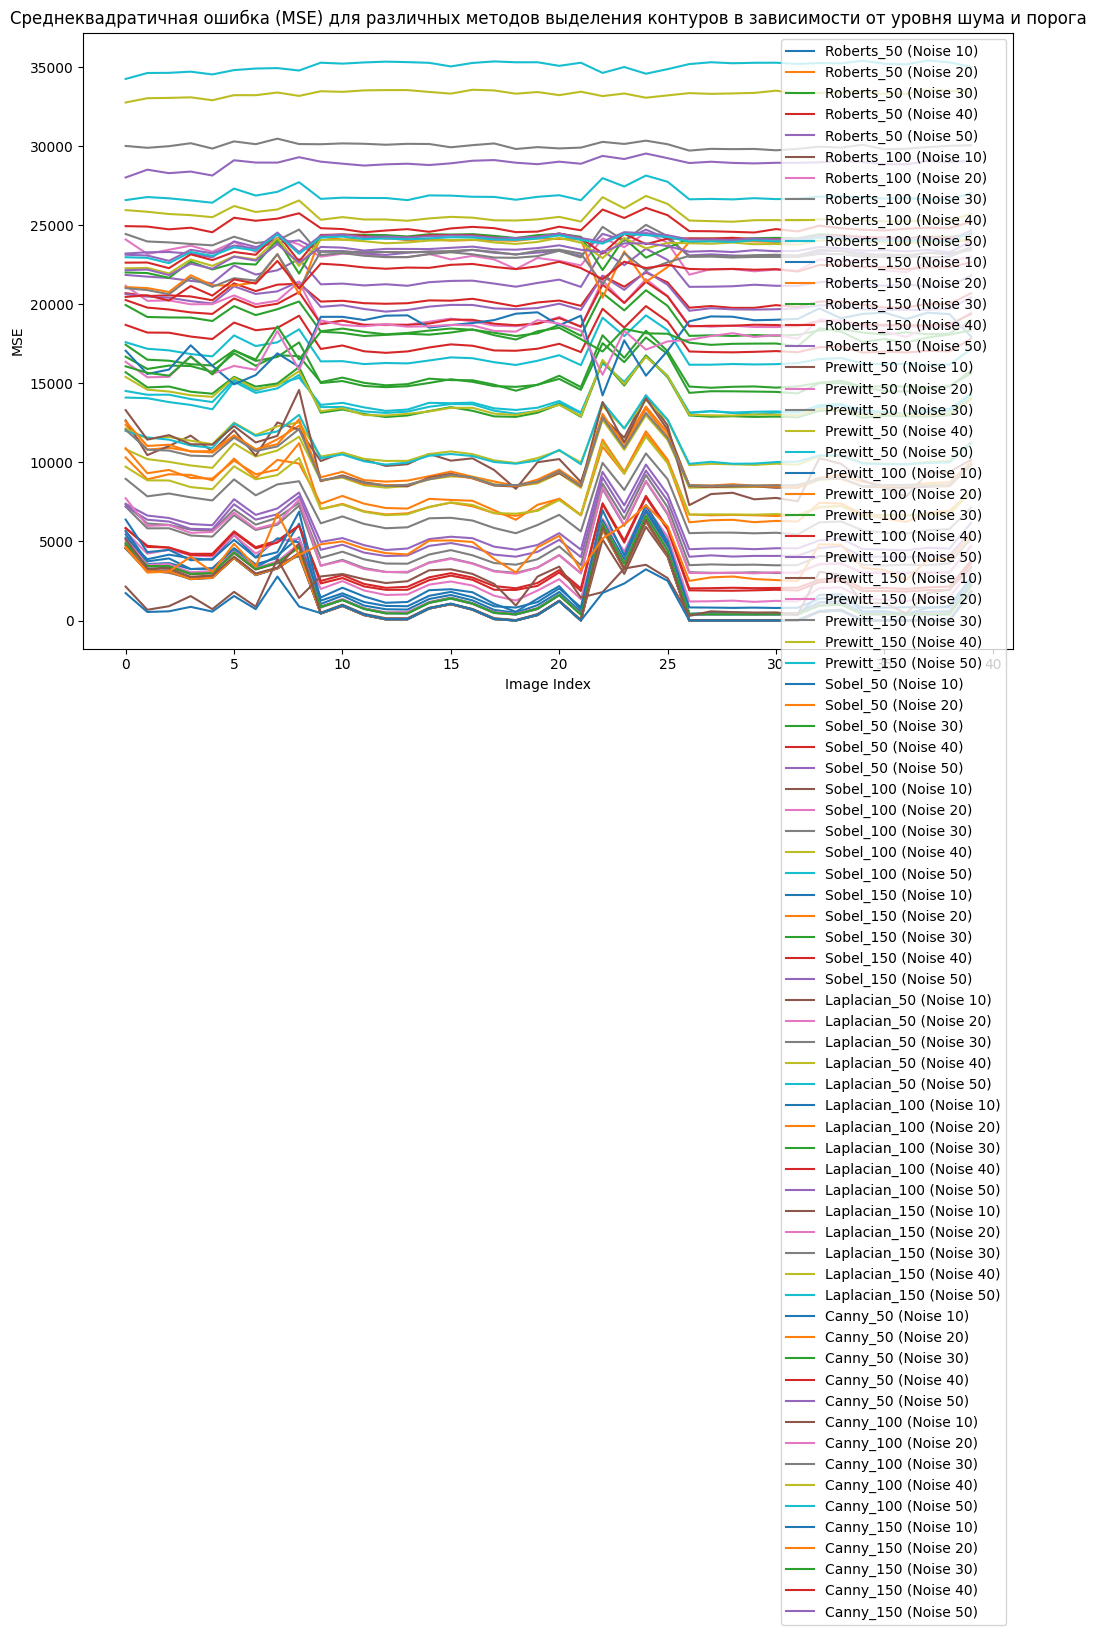

In [64]:

# Построение графиков MSE для каждого метода в зависимости от уровня шума
plt.figure(figsize=(12, 8))
for method, noise_data in mse_results.items():
    for noise_level, errors in noise_data.items():
        plt.plot(errors, label=f'{method} (Noise {noise_level})')

plt.xlabel('Image Index')
plt.ylabel('MSE')
plt.title('Среднеквадратичная ошибка (MSE) для различных методов выделения контуров в зависимости от уровня шума и порога')
plt.legend()
plt.show()

## Исследование детекторов и дескрипторов

In [65]:
# Путь к папке с изображениями
image_folder = 'sudoku dataset'

# Путь к папке для сохранения результатов
output_dir = 'detector_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [66]:
# Инициализация методов детекторов
detectors = {}
try:
    detectors["SIFT"] = cv2.SIFT_create()
except AttributeError:
    print("SIFT не поддерживается в данной версии OpenCV.")

try:
    detectors["SURF"] = cv2.xfeatures2d.SURF_create()
except AttributeError:
    print("SURF не поддерживается в данной версии OpenCV.")

try:
    detectors["BRISK"] = cv2.BRISK_create()
except AttributeError:
    print("BRISK не поддерживается в данной версии OpenCV.")

try:
    detectors["ORB"] = cv2.ORB_create()
except AttributeError:
    print("ORB не поддерживается в данной версии OpenCV.")


SURF не поддерживается в данной версии OpenCV.


In [67]:
# Функция для сохранения изображений с ключевыми точками
def save_keypoints_image(image, keypoints, title, folder_name):
    img_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    output_folder = os.path.join(output_dir, folder_name)
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    save_path = os.path.join(output_folder, f"{title}.jpg")
    cv2.imwrite(save_path, img_with_keypoints)


In [68]:
# Функция для чтения изображений из папки
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            img = cv2.imread(os.path.join(folder, filename))
            if img is not None:
                images.append((filename, img))
    return images

images = load_images_from_folder(image_folder)


In [69]:
# Обработка изображений с каждым методом
for name, detector in detectors.items():
    print(f"\nМетод: {name}")
    
    for filename, image in images:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Поиск ключевых точек и дескрипторов
        keypoints, descriptors = detector.detectAndCompute(gray, None)
        
        save_keypoints_image(image, keypoints, title=f"{filename}_{name}", folder_name=name)



Метод: SIFT

Метод: BRISK

Метод: ORB


Анализ инвариантности

In [70]:
def analyze_invariance(image, detector, detector_name, filename):
    transformations = {
        "Перемещение": lambda img: cv2.warpAffine(img, np.float32([[1, 0, 25], [0, 1, 25]]), img.shape[1::-1]),
        "Поворот": lambda img: cv2.warpAffine(img, cv2.getRotationMatrix2D((img.shape[1] // 2, img.shape[0] // 2), 45, 1.0), img.shape[1::-1]),
        "Изменение масштаба": lambda img: cv2.resize(img, None, fx=1.5, fy=1.5),
        "Изменение яркости": lambda img: cv2.convertScaleAbs(img, alpha=1.2, beta=30)
    }

    bf = cv2.BFMatcher()
    gray_original = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    kp_original, des_original = detector.detectAndCompute(gray_original, None)

    for transform_name, transform in transformations.items():
        transformed_image = transform(image)
        gray_transformed = cv2.cvtColor(transformed_image, cv2.COLOR_BGR2GRAY)
        kp_transformed, des_transformed = detector.detectAndCompute(gray_transformed, None)
        
        matches = bf.knnMatch(des_original, des_transformed, k=2)
        good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
        
        print(f"{filename} ({detector_name}) - {transform_name}: {len(good_matches)} совпадений")
        
        save_keypoints_image(transformed_image, kp_transformed, title=f"{filename}_{detector_name}_{transform_name}", folder_name=f"{detector_name}_invariance")


поиск похожих объектов с помощью дескрипторов методов на других изображениях

In [71]:
def compare_images(detector_name, detector):
    print(f"\nСравнение изображений методом: {detector_name}")
    bf = cv2.BFMatcher()
    for i in range(len(images)):
        filename1, img1 = images[i]
        gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
        kp1, des1 = detector.detectAndCompute(gray1, None)

        for j in range(i + 1, len(images)):
            filename2, img2 = images[j]
            gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
            kp2, des2 = detector.detectAndCompute(gray2, None)

            matches = bf.knnMatch(des1, des2, k=2)
            # Применить соотношение для отсеивания
            good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
            print(f"{filename1} vs {filename2}: {len(good_matches)} совпадений")

# Вызываем анализ инвариантности для каждого метода
for name, detector in detectors.items():
    for filename, img in images:
        analyze_invariance(img, detector, name, filename)

image1005.jpg (SIFT) - Перемещение: 2693 совпадений
image1005.jpg (SIFT) - Поворот: 1047 совпадений
image1005.jpg (SIFT) - Изменение масштаба: 1110 совпадений
image1005.jpg (SIFT) - Изменение яркости: 1241 совпадений
image1009.jpg (SIFT) - Перемещение: 2468 совпадений
image1009.jpg (SIFT) - Поворот: 1007 совпадений
image1009.jpg (SIFT) - Изменение масштаба: 1377 совпадений
image1009.jpg (SIFT) - Изменение яркости: 2554 совпадений
image1019.jpg (SIFT) - Перемещение: 4133 совпадений
image1019.jpg (SIFT) - Поворот: 1231 совпадений
image1019.jpg (SIFT) - Изменение масштаба: 1886 совпадений
image1019.jpg (SIFT) - Изменение яркости: 3491 совпадений
image1024.jpg (SIFT) - Перемещение: 3155 совпадений
image1024.jpg (SIFT) - Поворот: 1320 совпадений
image1024.jpg (SIFT) - Изменение масштаба: 1507 совпадений
image1024.jpg (SIFT) - Изменение яркости: 2319 совпадений
image1041.jpg (SIFT) - Перемещение: 3090 совпадений
image1041.jpg (SIFT) - Поворот: 976 совпадений
image1041.jpg (SIFT) - Изменение 

### распознавание сетки Судоку

In [72]:
def find_sudoku_grid(image):
    # Предобработка
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 50, 150)

    # Поиск контуров
    contours, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    sudoku_contour = None
    for contour in contours:
        approx = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
        if len(approx) == 4:
            sudoku_contour = approx
            break

    # Перспективное преобразование
    if sudoku_contour is not None and sudoku_contour.shape[0] == 4:
        # Преобразуем контур в массив точек
        pts = sudoku_contour.reshape(4, 2).astype("float32")
        rect = np.array(sorted(pts, key=lambda x: (x[1], x[0])))
        
        top_left, top_right, bottom_right, bottom_left = rect
        max_side = max(np.linalg.norm(top_right - top_left), np.linalg.norm(bottom_right - bottom_left),
                       np.linalg.norm(top_left - bottom_left), np.linalg.norm(top_right - bottom_right))
        
        dst = np.array([[0, 0], [max_side - 1, 0], [max_side - 1, max_side - 1], [0, max_side - 1]], dtype="float32")
        
        M = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(image, M, (int(max_side), int(max_side)))
        
        # Делим сетку на ячейки
        cells = []
        side = warped.shape[0] // 9
        for i in range(9):
            row = []
            for j in range(9):
                cell = warped[i*side:(i+1)*side, j*side:(j+1)*side]
                row.append(cell)
            cells.append(row)
        return cells
    else:
        print("Сетка судоку не найдена или содержит неверное количество точек.")
        return None


In [73]:
def process_sudoku_images(folder_path, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".jpg") or filename.endswith(".dat"):
            image_path = os.path.join(folder_path, filename)
            image = cv2.imread(image_path)
            
            if image is not None:
                cells = find_sudoku_grid(image)
                if cells is not None:
                    print(f"Сетка для {filename} найдена.")
                    for i, row in enumerate(cells):
                        for j, cell in enumerate(row):
                            cell_filename = f"{filename}_cell_{i}_{j}.png"
                            cell_path = os.path.join(output_folder, cell_filename)
                            cv2.imwrite(cell_path, cell)
                else:
                    print(f"Сетка для {filename} не найдена.")
            else:
                print(f"Не удалось загрузить {filename}")


In [74]:
image_folder = "sudoku dataset"
output_folder = "processed_cells"

# Запуск обработки всех изображений в папке
process_sudoku_images(image_folder, output_folder)

Не удалось загрузить image1005.dat
Сетка для image1005.jpg найдена.
Не удалось загрузить image1009.dat
Сетка для image1009.jpg найдена.
Не удалось загрузить image1019.dat
Сетка для image1019.jpg найдена.
Не удалось загрузить image1024.dat
Сетка для image1024.jpg найдена.
Не удалось загрузить image1041.dat
Сетка для image1041.jpg найдена.
Не удалось загрузить image1072.dat
Сетка для image1072.jpg найдена.
Не удалось загрузить image1073.dat
Сетка для image1073.jpg найдена.
Не удалось загрузить image1080.dat
Сетка для image1080.jpg найдена.
Не удалось загрузить image1088.dat
Сетка для image1088.jpg найдена.
Не удалось загрузить image114.dat
Сетка для image114.jpg найдена.
Не удалось загрузить image117.dat
Сетка для image117.jpg найдена.
Не удалось загрузить image120.dat
Сетка судоку не найдена или содержит неверное количество точек.
Сетка для image120.jpg не найдена.
Не удалось загрузить image126.dat
Сетка для image126.jpg найдена.
Не удалось загрузить image140.dat
Сетка для image140.jpg 

### MNIST

In [75]:
# Загружаем изображения MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### HOG

In [76]:
# Создаем папку для сохранения изображений с HOG, если она не существует
os.makedirs("HOG_images", exist_ok=True)

def extract_and_save_hog_features(images, labels, save_folder="HOG_images"):
    hog_features = []
    for idx, image in enumerate(images):
        # Извлекаем HOG-признаки
        features, hog_image = hog(image, orientations=9, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
        
        # Сохраняем HOG изображение
        hog_image_path = os.path.join(save_folder, f"hog_{idx}.png")
        cv2.imwrite(hog_image_path, (hog_image * 255).astype(np.uint8))
        
        # Добавляем HOG-признаки и метку к списку
        hog_features.append(features)
    
    return np.array(hog_features)

# Извлечение и сохранение HOG-признаков из обучающей и тестовой выборок
X_train_hog = extract_and_save_hog_features(X_train, y_train)
X_test_hog = extract_and_save_hog_features(X_test, y_test)

In [77]:
# Сохраняем HOG-признаки в CSV для обучающей выборки
train_df = pd.DataFrame(X_train_hog)
train_df['label'] = y_train
train_df.to_csv("train_hog_features.csv", index=False)

# Сохраняем HOG-признаки в CSV для тестовой выборки
test_df = pd.DataFrame(X_test_hog)
test_df['label'] = y_test
test_df.to_csv("test_hog_features.csv", index=False)

# Обучаем модель SVM на HOG-признаках
clf = SVC(kernel='linear', C=1.0)
clf.fit(X_train_hog, y_train)

# Предсказание на тестовой выборке
y_pred = clf.predict(X_test_hog)

# Вывод метрик точности и отчета
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9575
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.95      0.97      0.96      1032
           3       0.95      0.95      0.95      1010
           4       0.95      0.95      0.95       982
           5       0.97      0.95      0.96       892
           6       0.96      0.97      0.97       958
           7       0.96      0.94      0.95      1028
           8       0.95      0.94      0.94       974
           9       0.94      0.93      0.94      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



### SIFT

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

os.makedirs("SIFT_images", exist_ok=True)

def extract_sift_descriptors(images, sift):
    descriptors_list = []
    valid_indices = []  
    for idx, image in enumerate(images):
        img_cv = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        keypoints, descriptors = sift.detectAndCompute(img_cv, None)
        if descriptors is not None:
            descriptors_list.append(descriptors)
            valid_indices.append(idx)
    return descriptors_list, valid_indices

sift = cv2.SIFT_create()

X_train_descriptors, valid_train_indices = extract_sift_descriptors(X_train, sift)
X_test_descriptors, valid_test_indices = extract_sift_descriptors(X_test, sift)

y_train = y_train[valid_train_indices]
y_test = y_test[valid_test_indices]

# Объединяем все дескрипторы для создания словаря признаков
all_descriptors = np.vstack(X_train_descriptors)
n_clusters = 50  
kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=1000).fit(all_descriptors)

def get_bag_of_words(descriptors, kmeans, n_clusters):
    hist = np.zeros(n_clusters)
    if descriptors is not None:
        clusters = kmeans.predict(descriptors)
        for cluster in clusters:
            hist[cluster] += 1
    return hist

# Преобразуем дескрипторы в гистограммы признаков
X_train_bow = np.array([get_bag_of_words(d, kmeans, n_clusters) for d in X_train_descriptors])
X_test_bow = np.array([get_bag_of_words(d, kmeans, n_clusters) for d in X_test_descriptors])

# Нормализация признаков
scaler = StandardScaler()
X_train_bow = scaler.fit_transform(X_train_bow)
X_test_bow = scaler.transform(X_test_bow)

clf = SVC(kernel='linear', C=1.0)
clf.fit(X_train_bow, y_train)

y_pred = clf.predict(X_test_bow)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

### Распознавание сетки Судоку с помощью метода HOG

In [ ]:
from sklearn.tree import DecisionTreeClassifier
image_folder = 'sudoku dataset'
cell_size = (28, 28)  

In [ ]:
def read_dat_image(file_path, height=9, width=9):
    try:
        data = []
        with open(file_path, 'r') as file:
            for line in file:
                line = line.strip()
                if line and all(char.isdigit() or char.isspace() for char in line):
                    data.append(list(map(int, line.split())))
        data_array = np.array(data)
        if data_array.shape == (height, width):
            return data_array
        else:
            print(f"Неверные данные в файле {file_path}, пропуск...")
            return None
    except Exception as e:
        print(f"Ошибка при чтении {file_path}: {e}")
        return None

In [ ]:
def extract_cells_from_image(image_path):
   
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Unable to read image {image_path}")
    
    resized_image = cv2.resize(image, (252, 252)) 
    
    cells = []
    for i in range(9):
        for j in range(9):
            cell = resized_image[i * cell_size[0]:(i + 1) * cell_size[0],
                                 j * cell_size[1]:(j + 1) * cell_size[1]]
            cells.append(cell)
    return cells

In [ ]:
def extract_and_save_hog_features(cells, labels, save_folder="HOG_images_sudoku"):
    os.makedirs(save_folder, exist_ok=True)
    hog_features = []
    for idx, (cell, label) in enumerate(zip(cells, labels)):
        features, hog_image = hog(cell, orientations=9, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
        hog_image_path = os.path.join(save_folder, f"hog_{idx}.png")
        cv2.imwrite(hog_image_path, (hog_image * 255).astype(np.uint8))
        hog_features.append(features)
        #print(hog_features)
    return np.array(hog_features)

In [ ]:

images = []
labels = []

for file_name in os.listdir(image_folder):
    if file_name.endswith('.dat'):  
        file_path = os.path.join(image_folder, file_name)
        image_data = read_dat_image(file_path)
        
        if image_data is not None:
          
            image_file = file_name.replace('.dat', '.jpg')
            image_path = os.path.join(image_folder, image_file)
            
            if os.path.exists(image_path):
               
                cells = extract_cells_from_image(image_path)
                
                labels.extend(image_data.flatten())
                
                images.extend(cells)

if not images or not labels:
    raise ValueError("No images or labels were loaded. Check your dataset folder and file contents.")

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

X_train_hog = extract_and_save_hog_features(X_train, y_train)
X_test_hog = extract_and_save_hog_features(X_test, y_test)

train_df = pd.DataFrame(X_train_hog)
train_df['label'] = y_train

test_df = pd.DataFrame(X_test_hog)
test_df['label'] = y_test

clf = DecisionTreeClassifier()
#clf = SVC(kernel='linear', C=1.0)
clf.fit(X_train_hog, y_train)

y_pred = clf.predict(X_test_hog)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
print(y_pred)
print(y_test)

### Распознавание сетки Судоку с помощью метода SIFT

In [ ]:
image_folder = 'sudoku dataset'
cell_size = (28, 28)
n_clusters = 50  

In [ ]:
def read_dat_image(file_path, height=9, width=9):
    try:
        data = []
        with open(file_path, 'r') as file:
            for line in file:
                line = line.strip()
                if line and all(char.isdigit() or char.isspace() for char in line):
                    data.append(list(map(int, line.split())))
        data_array = np.array(data)
        if data_array.shape == (height, width):
            return data_array
        else:
            print(f"Неверные данные в файле {file_path}, пропуск...")
            return None
    except Exception as e:
        print(f"Ошибка при чтении {file_path}: {e}")
        return None

In [ ]:
def extract_cells_from_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Unable to read image {image_path}")
    
    resized_image = cv2.resize(image, (252, 252))
    cells = []
    for i in range(9):
        for j in range(9):
            cell = resized_image[i * cell_size[0]:(i + 1) * cell_size[0],
                                 j * cell_size[1]:(j + 1) * cell_size[1]]
            cells.append(cell)
    return cells


In [ ]:
def extract_sift_descriptors(cells):
    sift = cv2.SIFT_create()
    all_descriptors = []
    for cell in cells:
        keypoints, descriptors = sift.detectAndCompute(cell, None)
        if descriptors is not None:
            all_descriptors.extend(descriptors.astype(np.float32))
    return all_descriptors


In [ ]:
def compute_visual_words(cells, kmeans):
    sift = cv2.SIFT_create()
    histograms = []
    for cell in cells:
        _, descriptors = sift.detectAndCompute(cell, None)
        if descriptors is not None:
            #
            descriptors = descriptors.astype(np.float32)
            words = kmeans.predict(descriptors)
            hist, _ = np.histogram(words, bins=np.arange(n_clusters + 1))
        else:
            hist = np.zeros(n_clusters)
        histograms.append(hist)
    return np.array(histograms, dtype=np.float32) 


In [ ]:
images = []
labels = []

for file_name in os.listdir(image_folder):
    if file_name.endswith('.dat'):  
        file_path = os.path.join(image_folder, file_name)
        image_data = read_dat_image(file_path)
        
        if image_data is not None:
            image_file = file_name.replace('.dat', '.jpg')
            image_path = os.path.join(image_folder, image_file)
            
            if os.path.exists(image_path):
                cells = extract_cells_from_image(image_path)
                labels.extend(image_data.flatten())
                images.extend(cells)

if not images or not labels:
    raise ValueError("No images or labels were loaded. Check your dataset folder and file contents.")

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


train_descriptors = extract_sift_descriptors(X_train)

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(np.array(train_descriptors, dtype=np.float32)) 

X_train = compute_visual_words(X_train, kmeans)
X_test = compute_visual_words(X_test, kmeans)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))